In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from scipy import sparse

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA                 
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

np.set_printoptions(threshold=100, linewidth=120, suppress=True)
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


In [2]:
MAT_DIR = r"D:\Faisal\Resources\Brain Networks\smallgraphs"
META_PATH = r"D:\Faisal\Resources\Brain Networks\metainfo.xls"

mat_files = sorted([f for f in os.listdir(MAT_DIR) if f.endswith(".mat")])
ursi_from_files = [f.split('_')[0] for f in mat_files]
print(f"Found {len(mat_files)} .mat files in directory.")

meta_df = pd.read_excel(META_PATH) 
meta_df.columns = [c.strip() for c in meta_df.columns]
df = meta_df[meta_df["URSI"].isin(ursi_from_files)].copy()
df["filename"] = df["URSI"].apply(lambda x: f"{x}_fiber.mat")
df.reset_index(drop=True, inplace=True)
print(f"Matched {len(df)} metadata rows to files.")
print("-" * 30)
print(df[["URSI", "Sex", "Age", "Subject_type"]].head())

Found 114 .mat files in directory.
Matched 114 metadata rows to files.
------------------------------
        URSI  Sex  Age  Subject_type
0  M87102217    0   20             1
1  M87102806    0   20             0
2  M87103074    1   27             1
3  M87105476    0   21             0
4  M87107085    0   18             0


In [3]:
def load_and_process_graphs(file_list, data_dir):
    matrices = []
    
    print("Loading 114 brain graphs...")
    for f in file_list:
        path = os.path.join(data_dir, f)
        mat = loadmat(path)
        A = mat['fibergraph']
        if sparse.issparse(A):
            A = A.toarray()
        A = A.astype(float)
        
        A = 0.5 * (A + A.T)
        row_sums = A.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0 
        W = A / row_sums        
        matrices.append(W)
    return np.array(matrices)

Ws = load_and_process_graphs(df["filename"], MAT_DIR)
X_flat = Ws.reshape(Ws.shape[0], -1)
print("-" * 30)
print(f"3D Shape (for Vis): {Ws.shape}")
print(f"2D Shape (for ML):  {X_flat.shape}")

Loading 114 brain graphs...
------------------------------
3D Shape (for Vis): (114, 70, 70)
2D Shape (for ML):  (114, 4900)


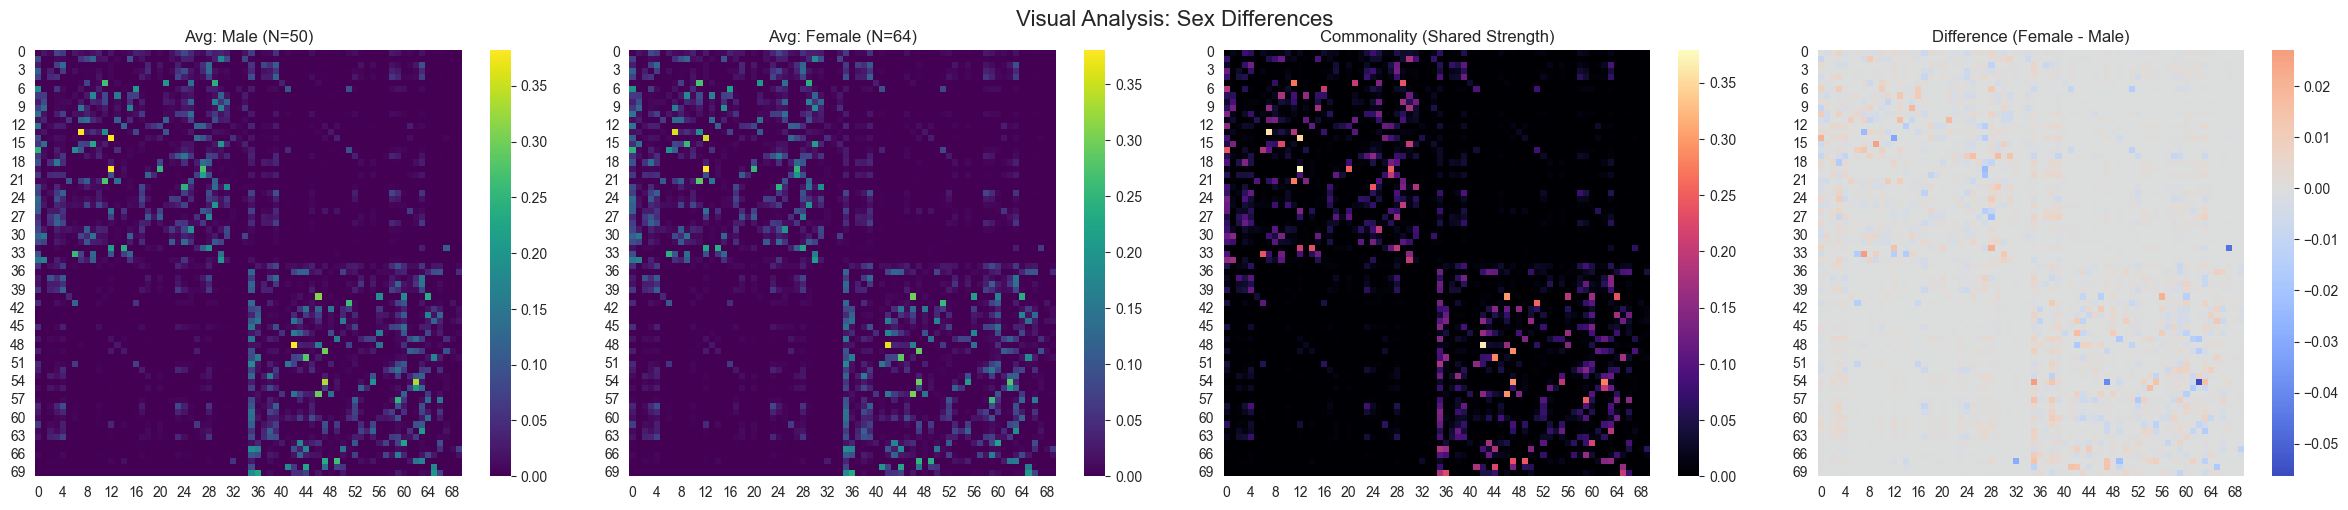

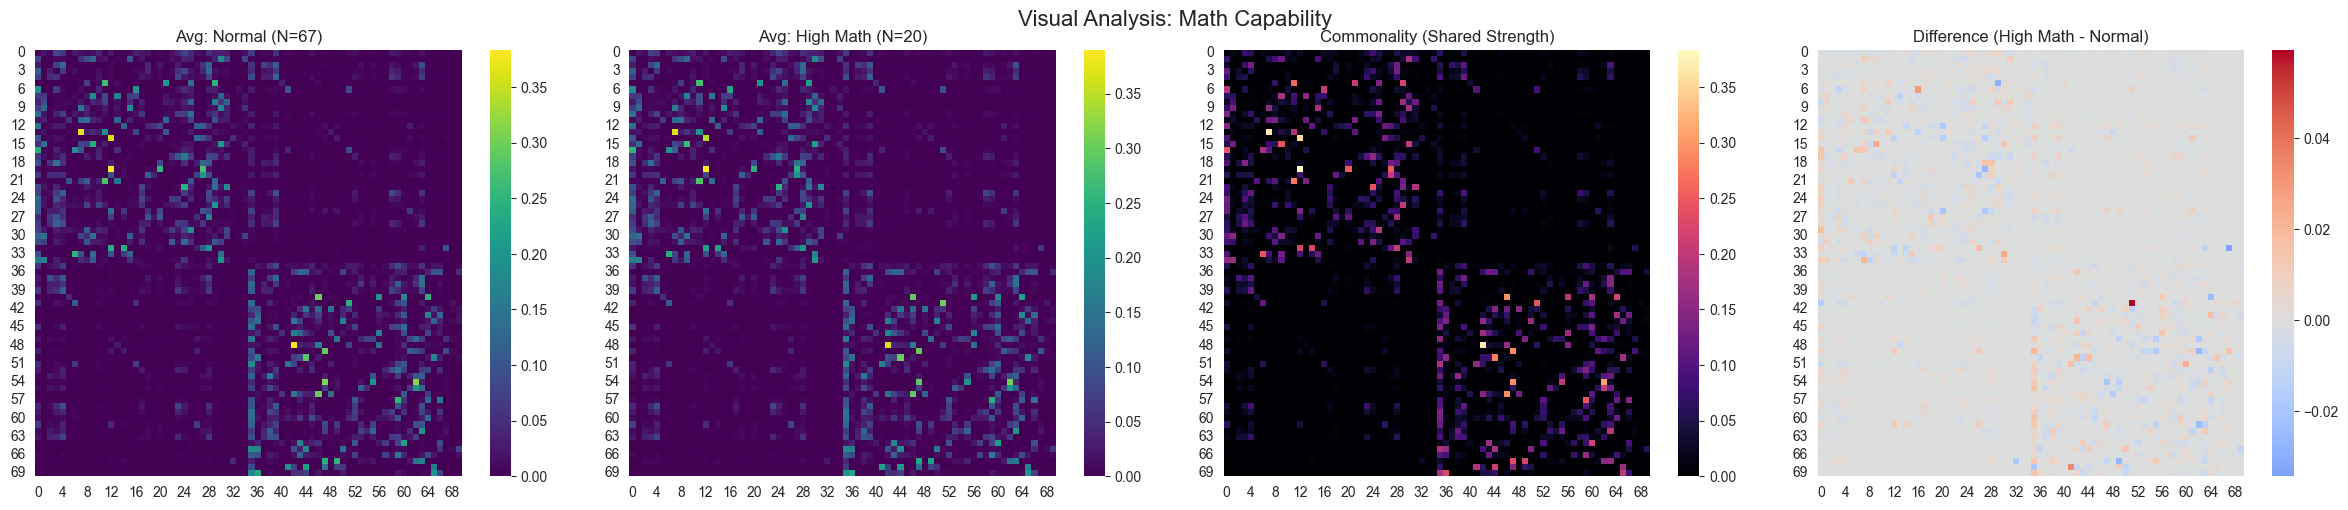

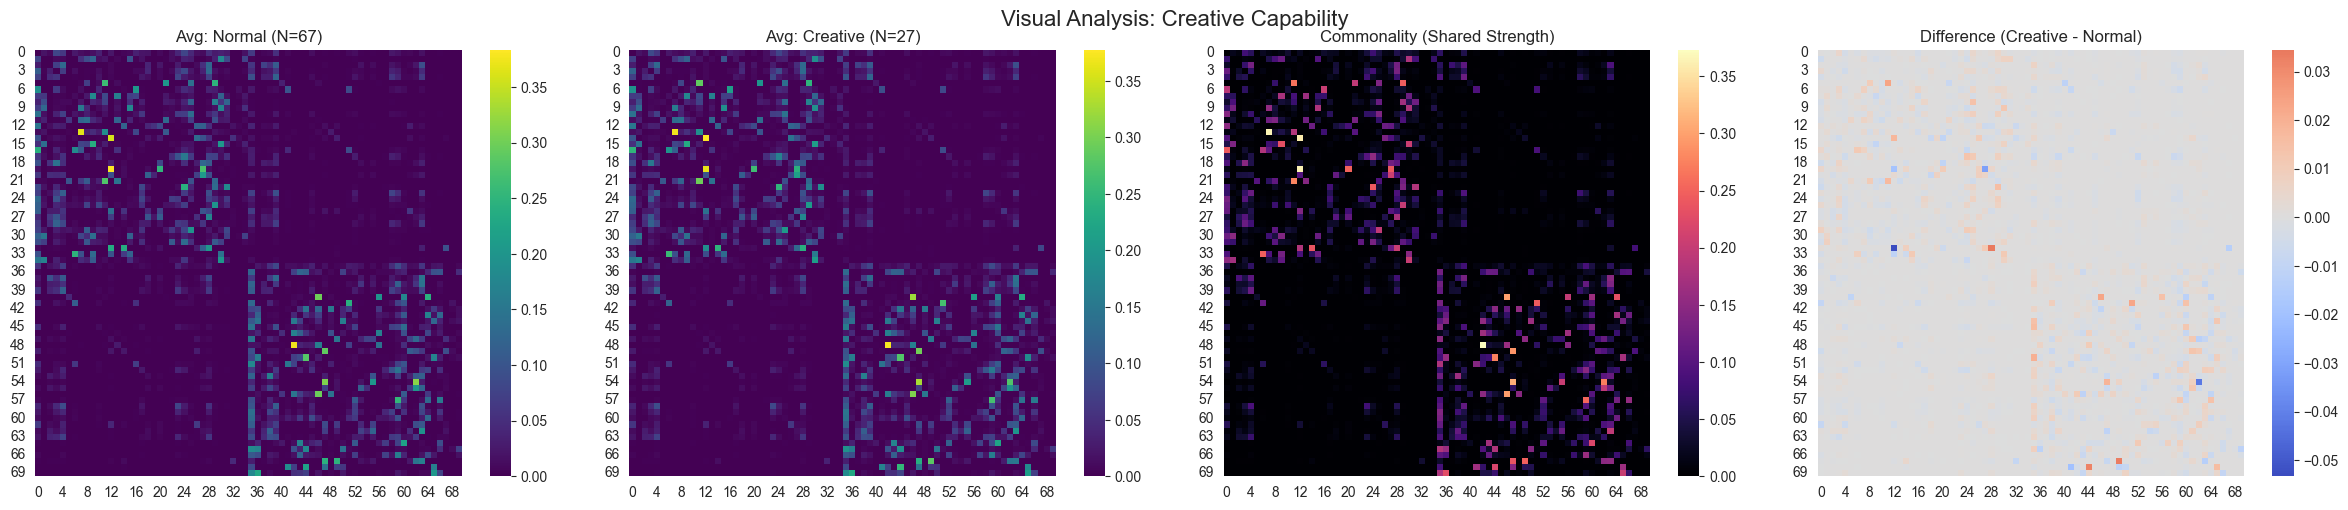

In [4]:
def visualize_group_difference(Ws, y, group_name_0, group_name_1, title):
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    avg_0 = np.mean(Ws[idx_0], axis=0)
    avg_1 = np.mean(Ws[idx_1], axis=0)
    common_brain = np.minimum(avg_0, avg_1)
    diff_brain = avg_1 - avg_0
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    sns.heatmap(avg_0, ax=axes[0], cmap="viridis", square=True)
    axes[0].set_title(f"Avg: {group_name_0} (N={len(idx_0)})")    
    sns.heatmap(avg_1, ax=axes[1], cmap="viridis", square=True)
    axes[1].set_title(f"Avg: {group_name_1} (N={len(idx_1)})")    
    sns.heatmap(common_brain, ax=axes[2], cmap="magma", square=True)
    axes[2].set_title("Commonality (Shared Strength)")    
    sns.heatmap(diff_brain, ax=axes[3], cmap="coolwarm", center=0, square=True)
    axes[3].set_title(f"Difference ({group_name_1} - {group_name_0})")
    plt.suptitle(f"Visual Analysis: {title}", fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_group_difference(Ws, df["Sex"].values, "Male", "Female", "Sex Differences")
mask_math = df["Subject_type"].isin([0, 2])
y_math = (df.loc[mask_math, "Subject_type"] == 2).astype(int).values
visualize_group_difference(Ws[mask_math], y_math, "Normal", "High Math", "Math Capability")
mask_cre = df["Subject_type"].isin([0, 1])
y_cre = (df.loc[mask_cre, "Subject_type"] == 1).astype(int).values
visualize_group_difference(Ws[mask_cre], y_cre, "Normal", "Creative", "Creative Capability")


Task: Sex (Male/Female)
Class Distribution: [50 64]

[Interpretation] Top Discriminative Connections:
  ROI 1 <--> ROI 13 (Score: 14.35)
  ROI 56 <--> ROI 55 (Score: 13.94)
  ROI 36 <--> ROI 70 (Score: 13.92)
  ROI 61 <--> ROI 44 (Score: 13.12)
  ROI 45 <--> ROI 44 (Score: 12.85)

[Performance]
  Accuracy: 0.667
  Balanced Acc: 0.655
  F1-Score: 0.716


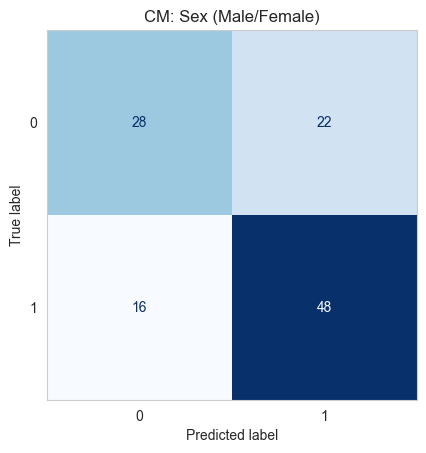


Task: Math (Normal/High)
Class Distribution: [67 20]

[Interpretation] Top Discriminative Connections:
  ROI 52 <--> ROI 61 (Score: 15.12)
  ROI 62 <--> ROI 63 (Score: 10.70)
  ROI 36 <--> ROI 27 (Score: 9.55)
  ROI 50 <--> ROI 63 (Score: 9.52)
  ROI 13 <--> ROI 21 (Score: 9.36)

[Performance]
  Accuracy: 0.655
  Balanced Acc: 0.496
  F1-Score: 0.211


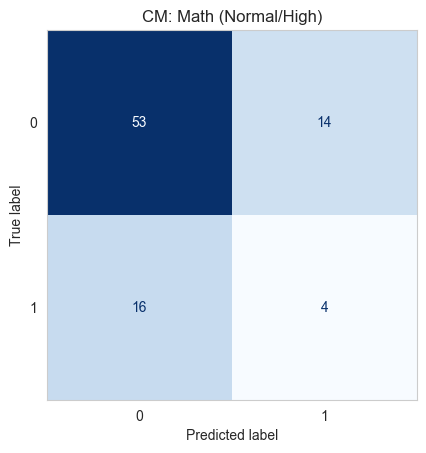


Task: Creative (SelectKBest)
Class Distribution: [67 27]

[Interpretation] Top Discriminative Connections:
  ROI 14 <--> ROI 24 (Score: 9.52)
  ROI 7 <--> ROI 8 (Score: 8.86)
  ROI 24 <--> ROI 14 (Score: 8.52)
  ROI 9 <--> ROI 26 (Score: 7.73)
  ROI 7 <--> ROI 16 (Score: 7.68)

[Performance]
  Accuracy: 0.468
  Balanced Acc: 0.350
  F1-Score: 0.074


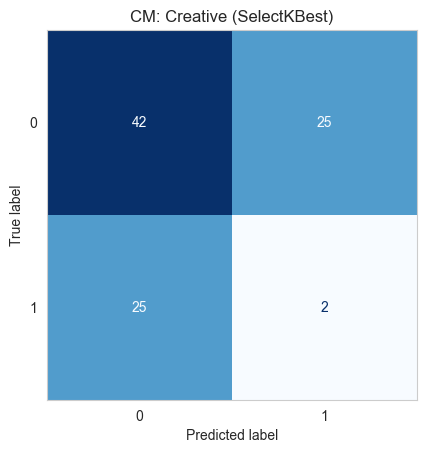


Task: Creative (PCA)
Class Distribution: [67 27]

[Performance]
  Accuracy: 0.457
  Balanced Acc: 0.454
  F1-Score: 0.320


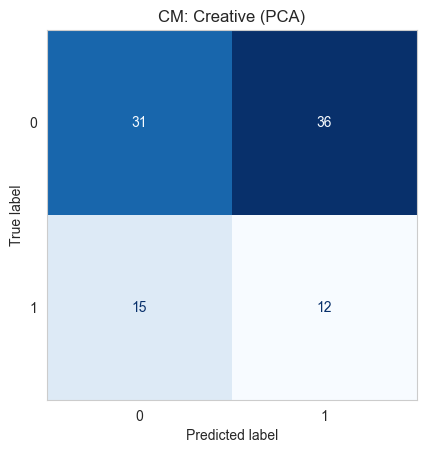


FINAL PROJECT SUMMARY TABLE
                        Accuracy  Balanced Acc  F1-Score
Sex (Male/Female)          0.667         0.655     0.716
Math (Normal/High)         0.655         0.496     0.211
Creative (SelectKBest)     0.468         0.350     0.074
Creative (PCA)             0.457         0.454     0.320
----------------------------------------


In [5]:
results_log = {}

def get_top_edges(selector, top_n=5):
    selected_indices = np.where(selector.get_support())[0]
    if len(selected_indices) == 0: return []
    
    scores = selector.scores_[selected_indices]
    sorted_idx = np.argsort(scores)[::-1][:top_n]
    
    top_edges = []
    for i in sorted_idx:
        flat_idx = selected_indices[i]
        roi_row = flat_idx // 70
        roi_col = flat_idx % 70
        top_edges.append((roi_row + 1, roi_col + 1, scores[i]))
    return top_edges

def eval_task_interpreted(X, y, task_name, use_pca=False):
    print(f"\n{'='*60}")
    print(f"Task: {task_name}")
    print(f"Class Distribution: {np.bincount(y)}")

    if use_pca:
        steps = [
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=20)),
            ('svm', SVC(kernel='rbf', C=1.0, class_weight='balanced'))
        ]
    else:
        steps = [
            ('scaler', StandardScaler()),
            ('selector', SelectKBest(f_classif, k=50)), 
            ('svm', SVC(kernel='rbf', C=1.0, class_weight='balanced'))
        ]        
        try:
            temp_selector = SelectKBest(f_classif, k=50)
            temp_selector.fit(StandardScaler().fit_transform(X), y)
            top_edges = get_top_edges(temp_selector)
            print("\n[Interpretation] Top Discriminative Connections:")
            for r1, r2, score in top_edges:
                print(f"  ROI {r1} <--> ROI {r2} (Score: {score:.2f})")
        except:
            pass
    pipe = Pipeline(steps)    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X, y, cv=cv)
    acc = accuracy_score(y, y_pred)
    bacc = balanced_accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, pos_label=1)
    results_log[task_name] = {
        'Accuracy': round(acc, 3), 
        'Balanced Acc': round(bacc, 3), 
        'F1-Score': round(f1, 3)
    }    
    print(f"\n[Performance]")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  Balanced Acc: {bacc:.3f}")
    print(f"  F1-Score: {f1:.3f}")

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"CM: {task_name}")
    plt.grid(False)
    plt.show()


import warnings
warnings.filterwarnings("ignore")
y_sex = pd.Categorical(df["Sex"]).codes
eval_task_interpreted(X_flat, y_sex, "Sex (Male/Female)")
mask_math = df["Subject_type"].isin([0, 2])
X_math = X_flat[mask_math]
y_math = (df.loc[mask_math, "Subject_type"] == 2).astype(int).values
eval_task_interpreted(X_math, y_math, "Math (Normal/High)")
mask_cre = df["Subject_type"].isin([0, 1])
X_cre = X_flat[mask_cre] 
y_cre = (df.loc[mask_cre, "Subject_type"] == 1).astype(int).values
eval_task_interpreted(X_cre, y_cre, "Creative (SelectKBest)")
eval_task_interpreted(X_cre, y_cre, "Creative (PCA)", use_pca=True)

print("\n" + "="*40)
print("FINAL PROJECT SUMMARY TABLE")
print("="*40)
df_results = pd.DataFrame(results_log).T
print(df_results)
print("-" * 40)